In [3]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import random_unitary
from qiskit_aer import AerSimulator
import mthree

In [4]:
def fourier_gate(d):
    """
    Generates a Fourier Transform gate for a d-dimensional system.
    F|j> = 1/sqrt(d) * sum_k (omega^(jk) |k>)
    """
    omega = np.exp(2j * np.pi / d)
    F = np.zeros((d, d), dtype=complex)
    for j in range(d):
        for k in range(d):
            F[k, j] = omega**(j * k) / np.sqrt(d)
    return F

def sum_gate(d):
    """
    Generates a SUM gate for a d-dimensional system (qudits).
    SUM|j>|k> = |j>|(j + k) mod d> 
    """
    dim = d**2
    SUM = np.zeros((dim, dim), dtype=complex)
    for j in range(d):
        for k in range(d):
            inp = j + k * d
            out = j + d * ((j + k) % d)
            SUM[out, inp] = 1
    return SUM

def x_gate(d):
    """
    Generates a genaralized X gate.
    X = sum_j |j><(j+1)%d|
    """
    X = np.zeros((d, d), dtype=complex)
    for j in range(d):
        X[j, (j + 1) % d] = 1
    return X

def z_gate(d):
    """
    Generates a generalized Z gate.
    Z = sum_j omega^j |j><j|
    """
    omega = np.exp(2j * np.pi / d)
    Z = np.zeros((d, d), dtype=complex)
    for j in range(d):
        Z[j, j] = omega**j
    return Z

In [33]:
def create_teleportation_circuit(d, seed=None):
    """
    Creates a quantum circuit for teleporting a d-dimensional state (qudit).
    """
    if (d & (d - 1)) != 0:
        raise ValueError("Dimension d must be a power of 2 for qubit mapping.")
    # Initialize Gates for dimension d
    F = fourier_gate(d)
    SUM = sum_gate(d)
    X = x_gate(d)
    Z = z_gate(d)
    # Random state preparation by unitary operator

    # Define registers and circuit
    # We map each qudit to log2(d) qubits, so we need log2(d) qubits for psi, A, and B each
    bits = int(np.log2(d))
    psi = QuantumRegister(bits, "psi")
    A = QuantumRegister(bits, "A")
    B = QuantumRegister(bits, "B")
    cr_n = ClassicalRegister(bits, "n")
    cr_m = ClassicalRegister(bits, "m")
    cr_z = ClassicalRegister(bits, "z")
    qc = QuantumCircuit(psi, A, B, cr_n, cr_m, cr_z)

    # Prepare completely UNKNOWN/RANDOM state psi
    U_prep = random_unitary(d, seed=seed)
    qc.unitary(U_prep, psi, label="U")
    qc.barrier()

    # We entangle Alice's and Bob's qudits mapped to log2​(d) qubits using the SUM and F gate
    qc.unitary(F, A, label=f"F{d}")
    qc.unitary(SUM, [*A,*B], label=f"SUM{d}")
    qc.barrier()

    # Now we apply the inverse of SUM and F gates to Alice's qudits mapped to log2​(d) qubits
    qc.unitary(SUM.T, [*psi,*A], label=f"SUM{d}†")
    qc.unitary(F.conj().T, psi, label=f"F{d}†")
    qc.barrier()

    # Now Alice measures her qudits mapped to log2​(d) qubits
    qc.measure(psi, cr_n)
    qc.measure(A, cr_m)

    # We apply the necessary gates to Bob's unknown state based on Alice's measurement results
    # Create all possible powers of X and Z for corrections
    X_powers = [np.linalg.matrix_power(X,i) for i in range(d)]
    Z_powers = [np.linalg.matrix_power(Z,i) for i in range(d)]
    # Apply Z^n correction based on n register
    for n in range(1, d):
        with qc.if_test((cr_n, n)):
            qc.unitary(Z_powers[n], B, label=f"Z^{n}")
    # Apply X^m correction based on m register
    for m in range(1, d):
        with qc.if_test((cr_m, m)):
            qc.unitary(X_powers[m], B, label=f"X^{m}")
    qc.barrier()

    # Finally, we apply the inverse of u to Bob's qudit mapped to log2​(d) qubits and measure for verification of the teleportation
    qc.unitary(U_prep.adjoint(), B, label="U†")
    qc.measure(B, cr_z)
    return qc

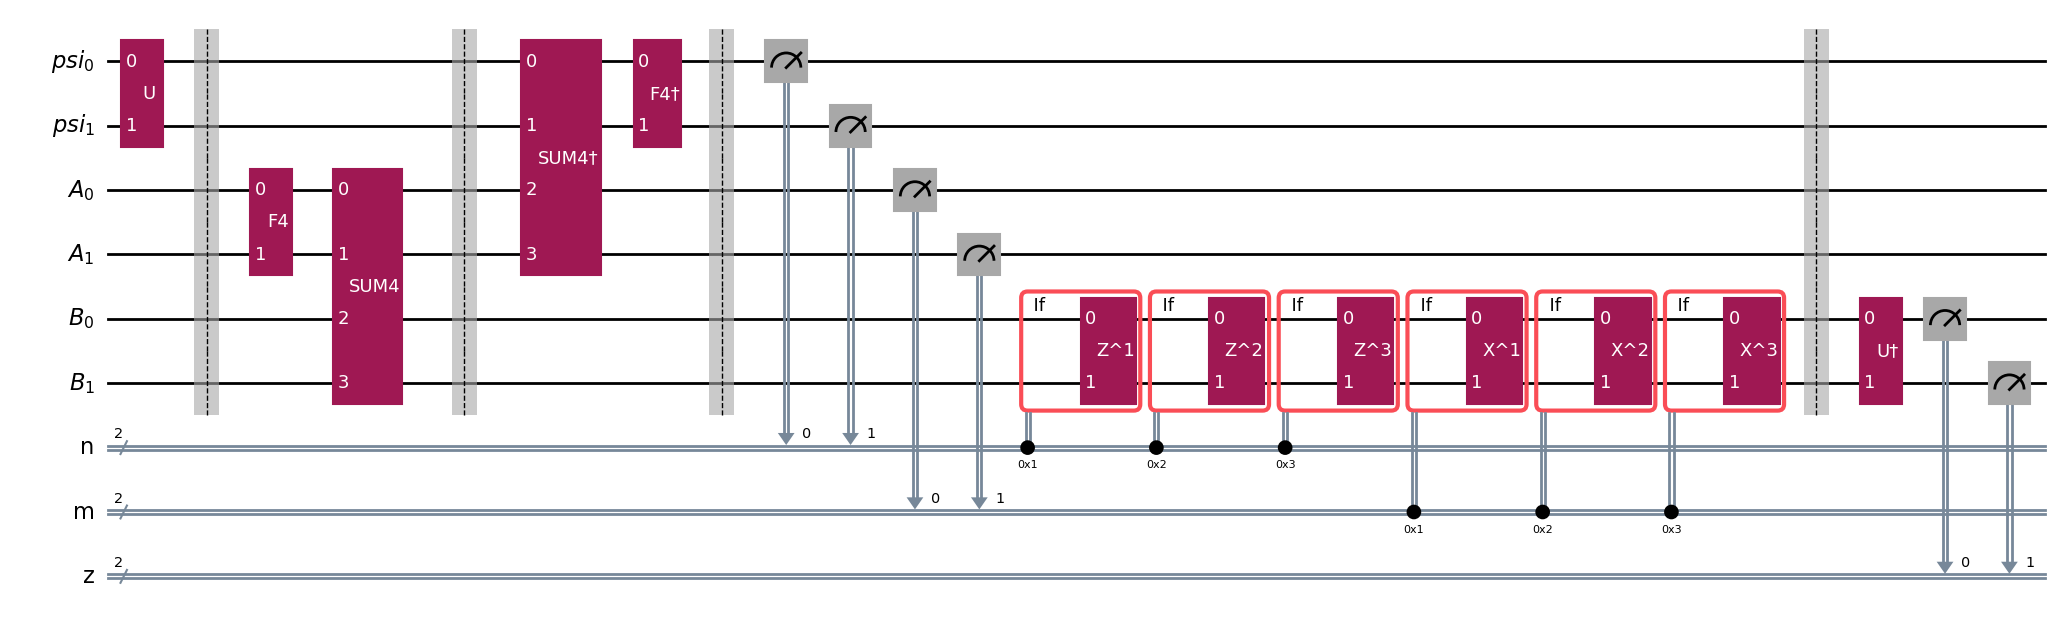

In [34]:
# Creating and visualizing the teleportation circuit for d=4 (2 qubits per qudit)
d = 4
qc = create_teleportation_circuit(d, seed=42)
fig = qc.draw(output="mpl", fold=100)
fig.savefig("results/circuit_qudit.png", dpi=600, bbox_inches="tight")
display(fig)

In [ ]:
# Initialize the AerSimulator and run on simulator
# sampler = SamplerV2(mode=AerSimulator())
# job = sampler.run([qc], shots=1024)
# res = job.result()

In [14]:
# Initialize runtime service and backend
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
# Optimize circuit for backend
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
# Run circuit using Sampler
sampler = SamplerV2(mode=backend)
job = sampler.run([qc_isa])
res = job.result()

Success rate: 67.94%


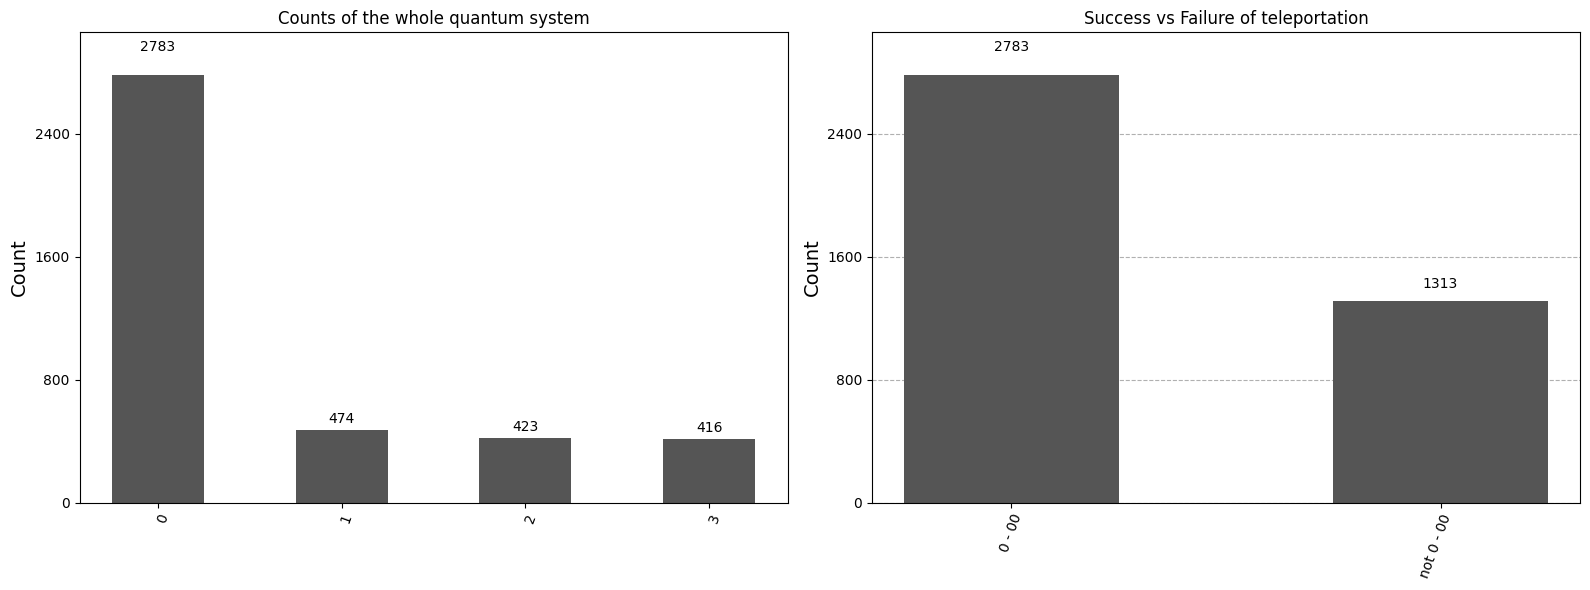

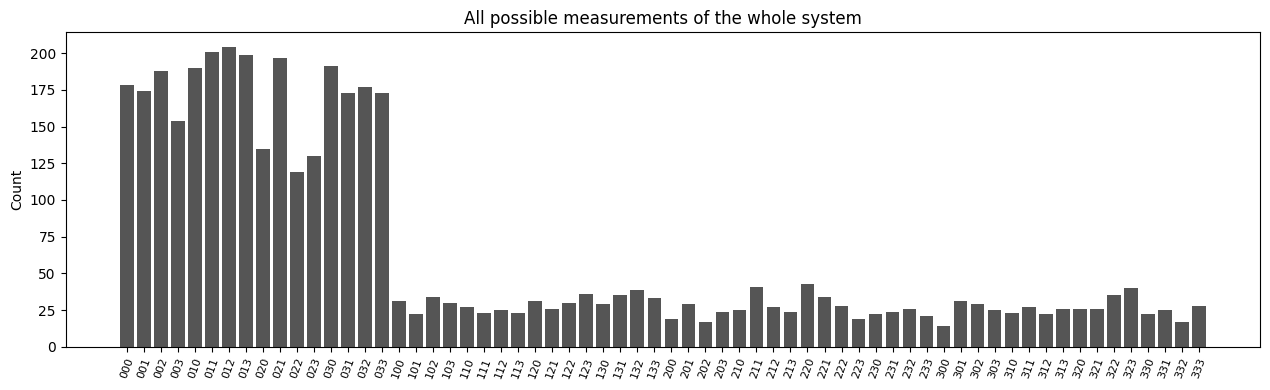

In [32]:
data = res[0].data
bits = int(np.log2(d))
counts = {}

bob_data = {str(i): 0 for i in range(d)}
all_states_data = {f"{z}{m}{n}": 0 for z in range(d) for m in range(d) for n in range(d)}

# Process all results in a single concise loop
for m_val, n_val, z_val in zip(data.m.get_bitstrings(), data.n.get_bitstrings(), data.z.get_bitstrings()):
    counts[z_val + m_val + n_val] = counts.get(z_val + m_val + n_val, 0) + 1
    
    z_v, m_v, n_v = str(int(z_val, 2)), str(int(m_val, 2)), str(int(n_val, 2))
    bob_data[z_v] += 1
    all_states_data[f"{z_v}{m_v}{n_v}"] += 1

total_shots = sum(counts.values())
success_count = bob_data.get('0', 0)
zero_str = f" - {'0' * bits}"
sf_data = { f"0{zero_str}": success_count, f"not 0{zero_str}": total_shots - success_count }

# Plot 1 & 2: Bob's State and Success metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_histogram(bob_data, ax=ax1, color='#555555')
ax1.set_title("Counts of the whole quantum system") 
plot_histogram(sf_data, ax=ax2, color='#555555', title="Success vs Failure of teleportation")
print(f"Success rate: {100 * success_count / total_shots:.2f}%")
plt.tight_layout()
fig.savefig("results/qudit_kingston_prob.png", dpi=600)
plt.show()

# Plot 3: All possible measurements
fig2 = plt.figure(figsize=(max(12, len(all_states_data) * 0.2), 4))
plt.bar(all_states_data.keys(), all_states_data.values(), color='#555555')
plt.title("All possible measurements of the whole system")
plt.xticks(rotation=70, fontsize=8)
plt.ylabel("Count")
plt.tight_layout()
fig2.savefig("results/qudit_kingston_all.png", dpi=600)
plt.show()

In [16]:
mit = mthree.M3Mitigation(backend)

# Mapping: classical bit index -> measured physical qubit
qubit_mapping = mthree.utils.final_measurement_mapping(qc_isa)
bits = int(np.log2(d))

# Build qubit list in classical-bit order
qubit_list = [qubit_mapping[i] for i in sorted(qubit_mapping)]

# calibration using the ordered physical qubits and apply the mitigation
mit.cals_from_system(qubit_list)
quasi = mit.apply_correction(counts, qubit_list)

print("Physical qubits used in classical-bit order:", qubit_list)
print(quasi)

Physical qubits used in classical-bit order: [93, 79, 94, 95, 73, 74]
{'000000': np.float32(0.043595336), '000001': np.float32(0.04216072), '000010': np.float32(0.046439547), '000011': np.float32(0.037362374), '000100': np.float32(0.04725053), '000101': np.float32(0.049697597), '000110': np.float32(0.051227123), '000111': np.float32(0.04954605), '001000': np.float32(0.032712035), '001001': np.float32(0.048316155), '001010': np.float32(0.028946012), '001011': np.float32(0.031452198), '001100': np.float32(0.047741827), '001101': np.float32(0.04252706), '001110': np.float32(0.044328455), '001111': np.float32(0.04297324), '010000': np.float32(0.007574628), '010001': np.float32(0.00515651), '010010': np.float32(0.008375985), '010011': np.float32(0.007318724), '010100': np.float32(0.006606536), '010101': np.float32(0.005472973), '010110': np.float32(0.006072272), '010111': np.float32(0.0055105775), '011000': np.float32(0.007633697), '011001': np.float32(0.0061350768), '011010': np.float32(0.

--- Teleportation Success Metric ---
Raw:       2783 / 4096 (0.6794)
Mitigated: 2810.99 / 4096 (0.6863)
Improvement: +0.68%


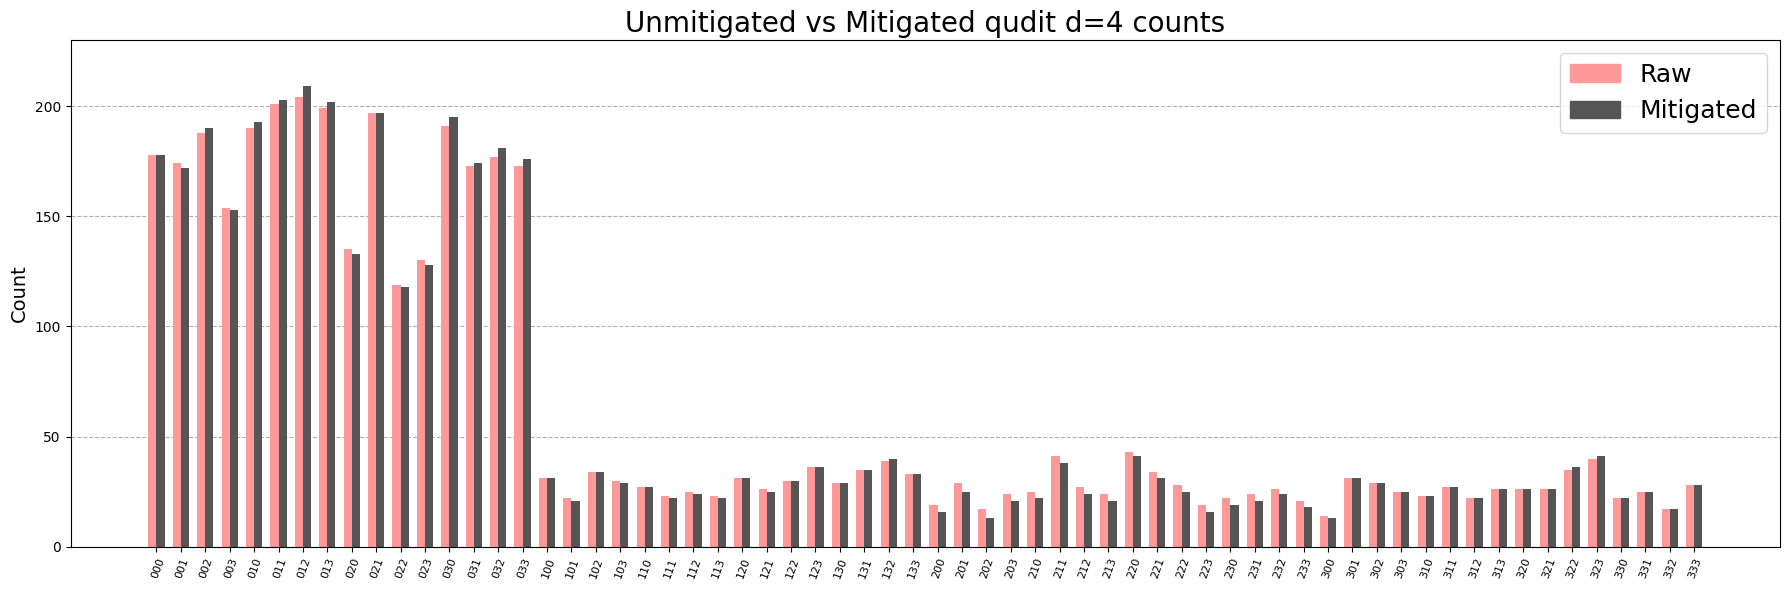

In [31]:
probs = quasi.nearest_probability_distribution()
bits = int(np.log2(d))

# Keep mitigated values as floats
mitigated_counts = {k: v * total_shots for k, v in probs.items()}

# Map binary string keys back to base-d representation strings
def to_base_d(bin_str):
    z_bin = bin_str[0:bits]
    m_bin = bin_str[bits:2*bits]
    n_bin = bin_str[2*bits:3*bits]
    return f"{int(z_bin, 2)}{int(m_bin, 2)}{int(n_bin, 2)}"

# Build mitigated Bob data and full-state data in the same way as for raw counts
mitigated_bob_data = {str(i): 0.0 for i in range(d)}
all_mapped_counts = {f"{z}{m}{n}": 0 for z in range(d) for m in range(d) for n in range(d)}
all_mapped_mitigated = {f"{z}{m}{n}": 0.0 for z in range(d) for m in range(d) for n in range(d)}

for k, v in counts.items():
    mapped = to_base_d(k)
    all_mapped_counts[mapped] += v

for k, v in mitigated_counts.items():
    mapped = to_base_d(k)
    all_mapped_mitigated[mapped] += v
    mitigated_bob_data[mapped[0]] += v

orig_succ = bob_data.get('0', 0)
mit_succ = mitigated_bob_data.get('0', 0.0)

print("--- Teleportation Success Metric ---")
print(f"Raw:       {orig_succ} / {total_shots} ({orig_succ/total_shots:.4f})")
print(f"Mitigated: {mit_succ:.2f} / {total_shots} ({mit_succ/total_shots:.4f})")
print(f"Improvement: {(mit_succ - orig_succ)/total_shots * 100:+.2f}%")

fig, ax = plt.subplots(figsize=(18, 6))

plot_histogram(
    [all_mapped_counts, all_mapped_mitigated],
    legend=['Raw', 'Mitigated'],
    color=['#ff9999', '#555555'],
    bar_labels=False,
    ax=ax
)
ax.set_title("Unmitigated vs Mitigated qudit d=4 counts", fontsize=20)

import matplotlib.patches as mpatches
raw_patch = mpatches.Patch(color='#ff9999', label='Raw')
mit_patch = mpatches.Patch(color='#555555', label='Mitigated')
ax.legend(handles=[raw_patch, mit_patch], loc='upper right', fontsize=18)

ax.tick_params(axis='x', rotation=70, labelsize=8)
plt.tight_layout()
fig.savefig("results/qudit_mitigated.png", dpi=600)
plt.show()